# Müşteri Yaşı, Demografik Özellikler ve Alışveriş Davranışlarının Harcama Üzerindeki Etkisinin İstatistiksel ve Veri Bilimi Yöntemleri ile Analizi


**Veri Seti:** E-Commerce Customer Behavior & Sales Analysis -TR
**Kaggle:** https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr?

---
## Özet
Bu çalışmada Türkiye e-ticaret pazarından elde edilen sentetik veri seti kullanılarak müşteri yaşı ve demografik özelliklerin harcama davranışları üzerindeki etkisi incelenmiştir. Betimsel istatistik, hipotez testleri (t-testi, ANOVA, Ki-kare), korelasyon analizi, çoklu doğrusal regresyon, rastgele orman ve yapay sinir ağı modelleri uygulanmıştır.

**Anahtar Kelimeler:** E-ticaret, Harcama Davranışı, Yaş Grupları, İstatistiksel Analiz, Makine Öğrenmesi, Yapay Sinir Ağı

---
## 1. Literatür Taraması

1. **Anderson & Srinivasan (2003)** – E-Satisfaction and E-Loyalty: demografik özelliklerin dijital platformlarda müşteri davranışını anlamlı biçimde etkilediği gösterilmiştir.
2. **Dittmar vd. (2004)** – Online alışverişte yaş ve cinsiyet farklılıkları incelenmiş; genç bireylerin teknoloji güdümlü alışveriş eğilimlerinin daha yüksek olduğu bulunmuştur.
3. **Hernández vd. (2011)** – Yaş arttıkça güven ve kolaylık faktörlerinin belirleyici hâle geldiği saptanmıştır.
4. **Swinyard & Smith (2003)** – Yaş ve gelirin temel ayrıştırıcı değişkenler olduğu ortaya konmuştur.
5. **Euromonitor International (2022)** – 35-54 yaş grubunun yüksek birim harcamayla öne çıktığı raporlanmıştır.
6. **TOBB E-Ticaret Raporu (2024)** – Türkiye'de elektronik ve giyim kategorisinin toplam e-ticaret gelirinin %60'ından fazlasını oluşturduğu belirtilmiştir.
7. **Kotler & Keller (2016)** – Yaş ve yaşam döngüsü evresinin harcama kalıplarını belirleyen başlıca unsurlar olduğu vurgulanmıştır.
8. **Bellman vd. (1999)** – Demografik değişkenlerin online harcama üzerindeki belirleyici etkisi istatistiksel yöntemlerle kanıtlanmıştır.

---
## 2. Kütüphanelerin Yüklenmesi

In [ ]:
# Temel veri işleme
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# İstatistiksel testler
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr, spearmanr, shapiro, levene
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Makine öğrenmesi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neural_network import MLPRegressor

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    TF_AVAILABLE = True
    print(f"TensorFlow {tf.__version__} yüklendi.")
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow bulunamadi. sklearn MLPRegressor kullanilacak.")

# Görsel ayarlar
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Tüm kütüphaneler yüklendi!")

TensorFlow 2.21.0 yüklendi.
Tüm kütüphaneler yüklendi!


---
## 3. Veri Seti Yükleme

In [ ]:
DOSYA_ADI = "ecommerce_customer_behavior_dataset.csv"

# Bütün sütunları kapsayan Türkçe sözlük eşleştirmesi
column_mapping = {
    'Order_ID': 'siparis_id',
    'Customer_ID': 'musteri_id',
    'Date': 'siparis_tarihi',
    'Age': 'yas',
    'Gender': 'cinsiyet',
    'City': 'sehir',
    'Product_Category': 'kategori',
    'Unit_Price': 'birim_fiyat',
    'Quantity': 'siparis_miktari',
    'Discount_Amount': 'indirim_tutari',
    'Total_Amount': 'toplam_harcama',
    'Payment_Method': 'odeme_yontemi',
    'Device_Type': 'cihaz_turu',
    'Session_Duration_Minutes': 'oturum_suresi_dk',
    'Pages_Viewed': 'goruntulenen_sayfa_sayisi',
    'Is_Returning_Customer': 'geri_gelen_musteri',
    'Delivery_Time_Days': 'teslimat_suresi_gun',
    'Customer_Rating': 'musteri_puani'
}

try:
    df_raw = pd.read_csv(DOSYA_ADI, encoding='utf-8-sig')
    print(f"✅ Başarılı: Veri seti sorunsuz şekilde yüklendi!")
    print(f"Veri seti boyutu: {df_raw.shape[0]:,} satır x {df_raw.shape[1]} sütun")
    
    df = df_raw.copy()
    
    df.rename(columns=column_mapping, inplace=True)
    print("✅ Başarılı: Sütun isimleri Türkçe yapıldı!")
    
    print("\nYeni Sütun Adları ve Veri Tipleri:")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i:2}. {col:25s}  ({df[col].dtype})")

except FileNotFoundError:
    print(f"❌ HATA: '{DOSYA_ADI}' dosyası bulunamadı!")
    print("Lütfen şunları kontrol et:")
    print("1. Dosyanın adının tam olarak doğru olduğundan (büyük/küçük harf veya sonundaki .csv uzantısı).")
    print("2. CSV dosyasını, şu an çalıştığın notebook (.ipynb) dosyası ile AYNI klasöre koyduğundan.")



✅ Başarılı: Veri seti sorunsuz şekilde yüklendi!
Veri seti boyutu: 5,000 satır x 18 sütun
✅ Başarılı: Sütun isimleri Türkçe yapıldı!

Yeni Sütun Adları ve Veri Tipleri:
   1. siparis_id                 (object)
   2. musteri_id                 (object)
   3. siparis_tarihi             (object)
   4. yas                        (int64)
   5. cinsiyet                   (object)
   6. sehir                      (object)
   7. kategori                   (object)
   8. birim_fiyat                (float64)
   9. siparis_miktari            (int64)
  10. indirim_tutari             (float64)
  11. toplam_harcama             (float64)
  12. odeme_yontemi              (object)
  13. cihaz_turu                 (object)
  14. oturum_suresi_dk           (int64)
  15. goruntulenen_sayfa_sayisi  (int64)
  16. geri_gelen_musteri         (bool)
  17. teslimat_suresi_gun        (int64)
  18. musteri_puani              (int64)


---
## 4. Veri Temizleme

In [12]:
# Eksik veri analizi
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Eksik Sayi': missing, 'Eksik Oran (%)': missing_pct})
missing_df = missing_df[missing_df['Eksik Sayi'] > 0].sort_values('Eksik Oran (%)', ascending=False)

if len(missing_df) == 0:
    print("Eksik deger bulunmamaktadir.")
else:
    print(missing_df)

# Sayisal: medyan, kategorik: mod ile doldur
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col}: medyan ile dolduruldu")

for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  {col}: mod ile dolduruldu")

print(f"\nTemizleme sonrasi eksik deger: {df.isnull().sum().sum()}")
print(f"Veri boyutu: {df.shape}")

Eksik deger bulunmamaktadir.

Temizleme sonrasi eksik deger: 0
Veri boyutu: (5000, 18)


---
## 5. Aykırı Değer Analizi (IQR)

AYKIRI DEGER ANALİZİ
----------------------------------------------------------------------
  yas                       | IQR=   15.00 | Aykiri=30 (0.6%)
  birim_fiyat               | IQR=  437.34 | Aykiri=513 (10.3%)
  siparis_miktari           | IQR=    2.00 | Aykiri=0 (0.0%)
  indirim_tutari            | IQR=    8.76 | Aykiri=879 (17.6%)
  toplam_harcama            | IQR=  857.18 | Aykiri=0 (0.0%)
  oturum_suresi_dk          | IQR=   11.00 | Aykiri=124 (2.5%)
  goruntulenen_sayfa_sayisi | IQR=    4.00 | Aykiri=14 (0.3%)
  teslimat_suresi_gun       | IQR=    4.00 | Aykiri=141 (2.8%)
  musteri_puani             | IQR=    2.00 | Aykiri=0 (0.0%)

Winsorization: toplam_harcama [0.00, 2265.46] araligina sinirlandirildi


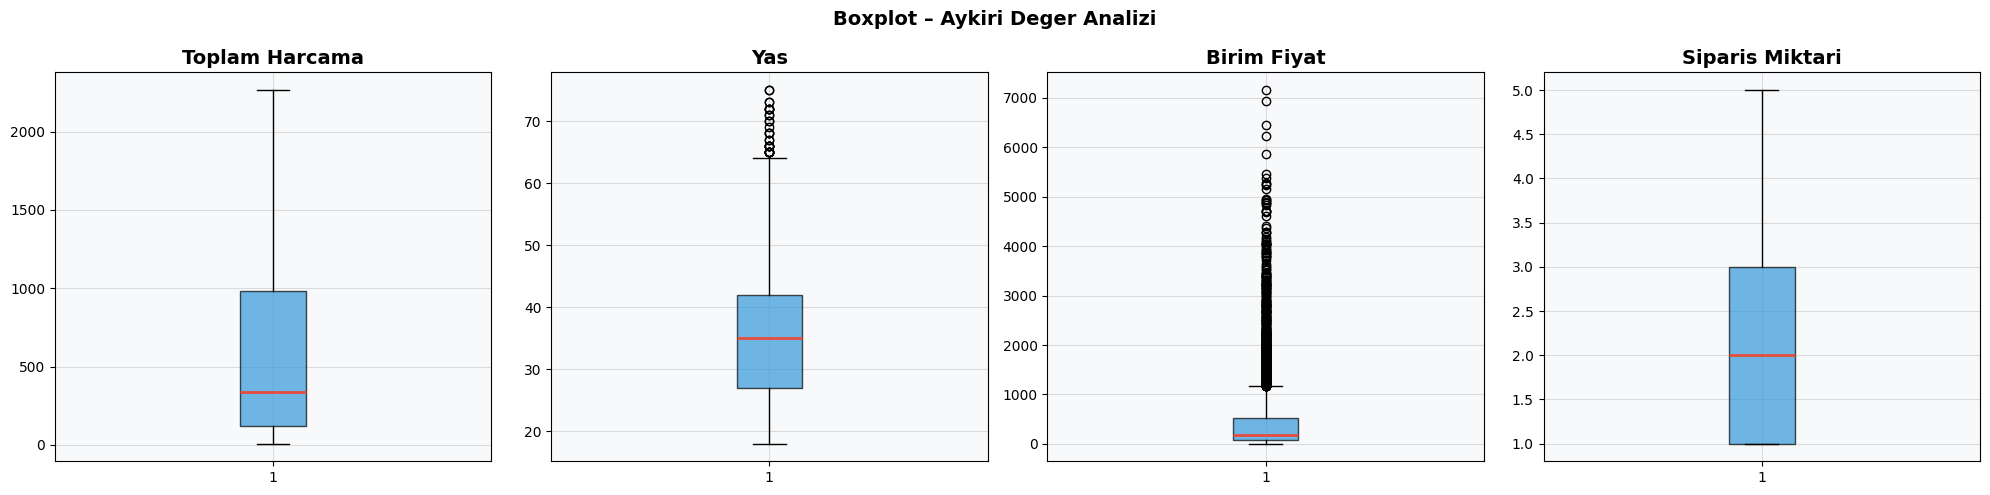

In [33]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("AYKIRI DEGER ANALİZİ")
print("-" * 70)
for col in num_cols:
    if col not in df.columns:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"  {col:25s} | IQR={IQR:8.2f} | Aykiri={n_out} ({n_out/len(df)*100:.1f}%)")

# Winsorization (toplam_harcama)
if 'toplam_harcama' in df.columns:
    Q1 = df['toplam_harcama'].quantile(0.25)
    Q3 = df['toplam_harcama'].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    
    # E-ticarette eksi harcama olamayacağı için alt sınırı 0 ile güvenceye alıyoruz
    lo_adjusted = max(0, lo) 
    df['toplam_harcama'] = df['toplam_harcama'].clip(lo_adjusted, hi)
    print(f"\nWinsorization: toplam_harcama [{lo_adjusted:.2f}, {hi:.2f}] araligina sinirlandirildi")

# Boxplot
plot_cols = [c for c in ['toplam_harcama','yas','birim_fiyat','siparis_miktari'] if c in df.columns]
if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(5*len(plot_cols), 5))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        ax.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#3498DB', alpha=0.7),
                   medianprops=dict(color='#E74C3C', linewidth=2))
        ax.set_title(col.replace('_',' ').title(), fontweight='bold')
    plt.suptitle('Boxplot – Aykiri Deger Analizi', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafik_01_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Yaş Gruplandırma

In [ ]:
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
bins = [17, 25, 35, 45, 60, np.inf] 
palette = ['#E74C3C','#E67E22','#2ECC71','#3498DB','#9B59B6']

if 'yas' in df.columns:
    print("Eksik yas sayisi:", df['yas'].isna().sum())
    print("Negatif yas sayisi:", (df['yas'] < 0).sum())
    print("120+ yas sayisi:", (df['yas'] > 120).sum())

    df = df[(df['yas'].notna()) & (df['yas'] >= 18) & (df['yas'] <= 120)].copy() # .copy() eklemek sonradan hata almanı önler
    
    df['yas_grubu'] = pd.cut(
        df['yas'],
        bins=bins,
        labels=labels,
        right=True
    )
    df['yas_grubu'] = pd.Categorical(df['yas_grubu'], categories=labels, ordered=True)

    print("\nYas Grubu Dagilimi:")
    print(df['yas_grubu'].value_counts().sort_index())

    print(f"\nOrtalama Yas: {df['yas'].mean():.1f}")
    print(f"Medyan Yas  : {df['yas'].median():.1f}")
else:
    print("UYARI: 'yas' sütunu bulunamadi!")

Eksik yas sayisi: 0
Negatif yas sayisi: 0
120+ yas sayisi: 0

Yas Grubu Dagilimi:
yas_grubu
18-25    1125
26-35    1514
36-45    1470
46-60     824
60+        67
Name: count, dtype: int64

Ortalama Yas: 35.0
Medyan Yas  : 35.0


---
## 7. Betimsel İstatistik

In [35]:
def desc_stats(series, name):
    s = series.dropna()
    return {
        'Degisken': name, 'N': len(s),
        'Ortalama': round(s.mean(),3), 'Medyan': round(s.median(),3),
        'Mod': round(s.mode().iloc[0],3) if not s.mode().empty else 'N/A',
        'Std Sapma': round(s.std(),3), 'Varyans': round(s.var(),3),
        'Min': round(s.min(),3), 'Max': round(s.max(),3),
        'Q1': round(s.quantile(0.25),3), 'Q3': round(s.quantile(0.75),3),
        'IQR': round(s.quantile(0.75)-s.quantile(0.25),3),
        'Carpiklik': round(s.skew(),3), 'Basiklik': round(s.kurtosis(),3),
    }

stat_cols = [c for c in ['toplam_harcama','yas','birim_fiyat','siparis_miktari','musteri_puani']
             if c in df.columns]
stats_table = pd.DataFrame([desc_stats(df[c], c) for c in stat_cols]).set_index('Degisken')

print("BETİMSEL İSTATİSTİK TABLOSU")
display(stats_table)

if 'yas_grubu' in df.columns:
    print("\nYas Grubuna Gore Harcama:")
    yas_st = df.groupby('yas_grubu', observed=True)['toplam_harcama'].agg(
        N='count', Ortalama='mean', Medyan='median', Std='std', Min='min', Max='max').round(2)
    display(yas_st)

BETİMSEL İSTATİSTİK TABLOSU


,N,Ortalama,Medyan,Mod,Std Sapma,Varyans,Min,Max,Q1,Q3,IQR,Carpiklik,Basiklik
Degisken,,,,,,,,,,,,,
toplam_harcama,5000,672.895,337.91,2265.461,733.097,537431.745,7.87,2265.461,122.518,979.695,857.177,1.200,0.063
yas,5000,35.033,35.00,18.000,11.081,122.778,18.00,75.000,27.000,42.000,15.000,0.336,-0.369
birim_fiyat,5000,455.834,182.95,30.100,712.477,507623.773,5.18,7159.450,76.588,513.930,437.343,3.471,15.983
siparis_miktari,5000,2.220,2.00,1.000,1.399,1.956,1.00,5.000,1.000,3.000,2.000,0.825,-0.694
musteri_puani,5000,3.903,4.00,5.000,1.129,1.274,1.00,5.000,3.000,5.000,2.000,-0.949,0.134



Yas Grubuna Gore Harcama:


,N,Ortalama,Medyan,Std,Min,Max
yas_grubu,,,,,,
18-25,1125,691.40,348.10,757.79,8.33,2265.46
26-35,1514,644.65,324.52,711.19,7.87,2265.46
36-45,1470,690.51,344.92,739.80,7.89,2265.46
46-60,824,674.35,342.22,734.03,10.86,2265.46
60+,67,596.15,360.41,628.30,20.29,2265.46


---
## 8. Keşifçi Veri Analizi (EDA)

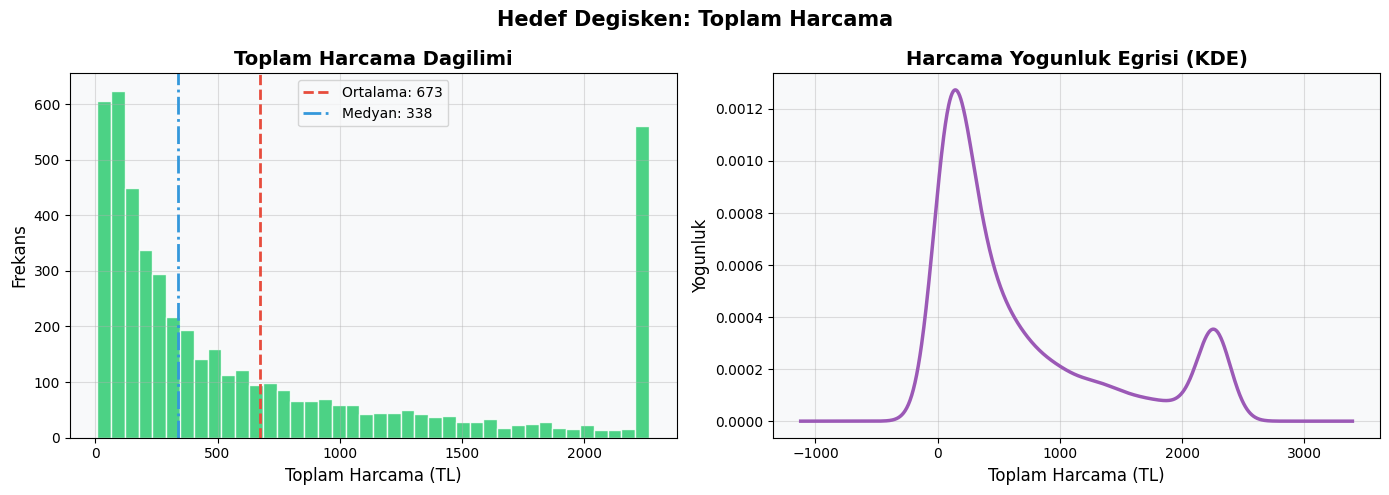

Carpiklik: 1.200
Basiklik : 0.063


In [16]:
# Hedef degisken dagilimi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['toplam_harcama'].dropna(), bins=40, color='#2ECC71', edgecolor='white', alpha=0.85)
axes[0].axvline(df['toplam_harcama'].mean(), color='#E74C3C', linestyle='--', linewidth=2,
                label=f"Ortalama: {df['toplam_harcama'].mean():.0f}")
axes[0].axvline(df['toplam_harcama'].median(), color='#3498DB', linestyle='-.', linewidth=2,
                label=f"Medyan: {df['toplam_harcama'].median():.0f}")
axes[0].set_title('Toplam Harcama Dagilimi', fontweight='bold')
axes[0].set_xlabel('Toplam Harcama (TL)')
axes[0].set_ylabel('Frekans')
axes[0].legend()

df['toplam_harcama'].dropna().plot(kind='kde', ax=axes[1], color='#9B59B6', linewidth=2.5)
axes[1].set_title('Harcama Yogunluk Egrisi (KDE)', fontweight='bold')
axes[1].set_xlabel('Toplam Harcama (TL)')
axes[1].set_ylabel('Yogunluk')

plt.suptitle('Hedef Degisken: Toplam Harcama', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik_02_harcama_dagilim.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Carpiklik: {df['toplam_harcama'].skew():.3f}")
print(f"Basiklik : {df['toplam_harcama'].kurtosis():.3f}")

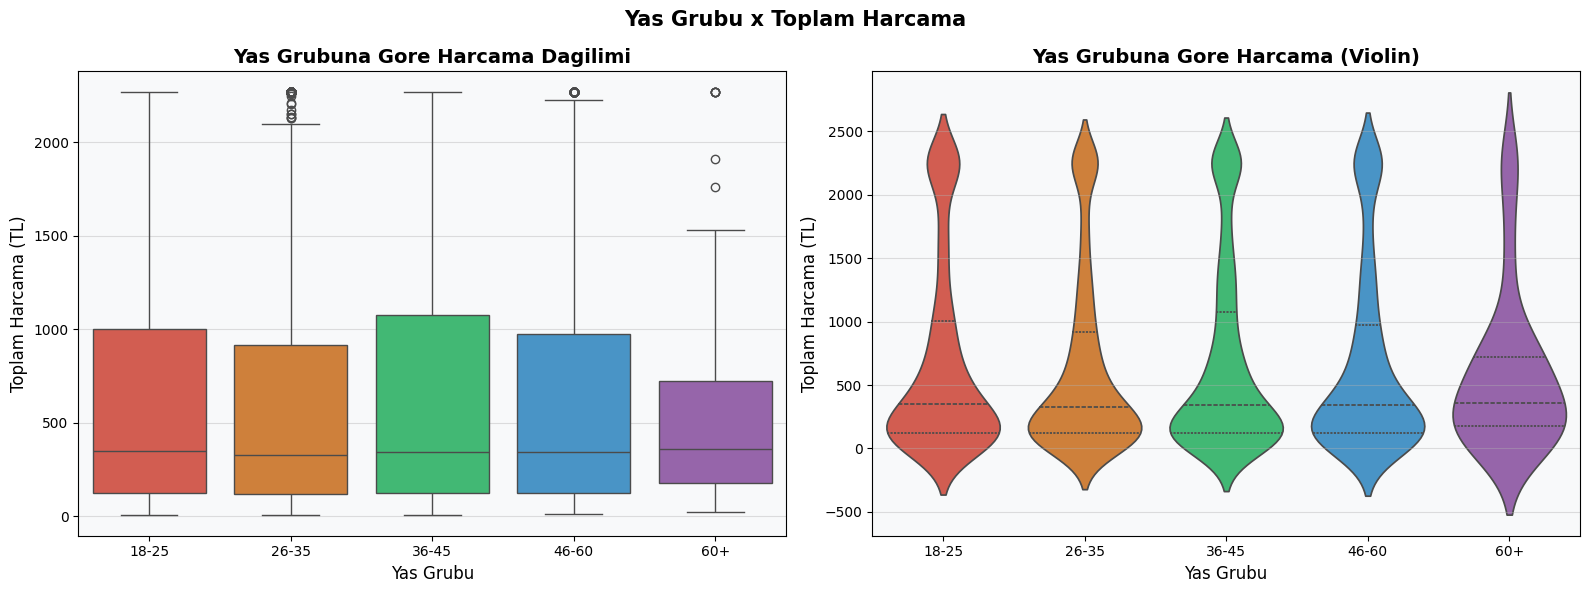

In [17]:
# Yas grubuna gore boxplot + violin
if 'yas_grubu' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.boxplot(data=df, x='yas_grubu', y='toplam_harcama',
                palette=palette, order=labels, ax=axes[0])
    axes[0].set_title('Yas Grubuna Gore Harcama Dagilimi', fontweight='bold')
    axes[0].set_xlabel('Yas Grubu')
    axes[0].set_ylabel('Toplam Harcama (TL)')

    sns.violinplot(data=df, x='yas_grubu', y='toplam_harcama',
                   palette=palette, order=labels, ax=axes[1], inner='quartile')
    axes[1].set_title('Yas Grubuna Gore Harcama (Violin)', fontweight='bold')
    axes[1].set_xlabel('Yas Grubu')
    axes[1].set_ylabel('Toplam Harcama (TL)')

    plt.suptitle('Yas Grubu x Toplam Harcama', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafik_03_yas_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

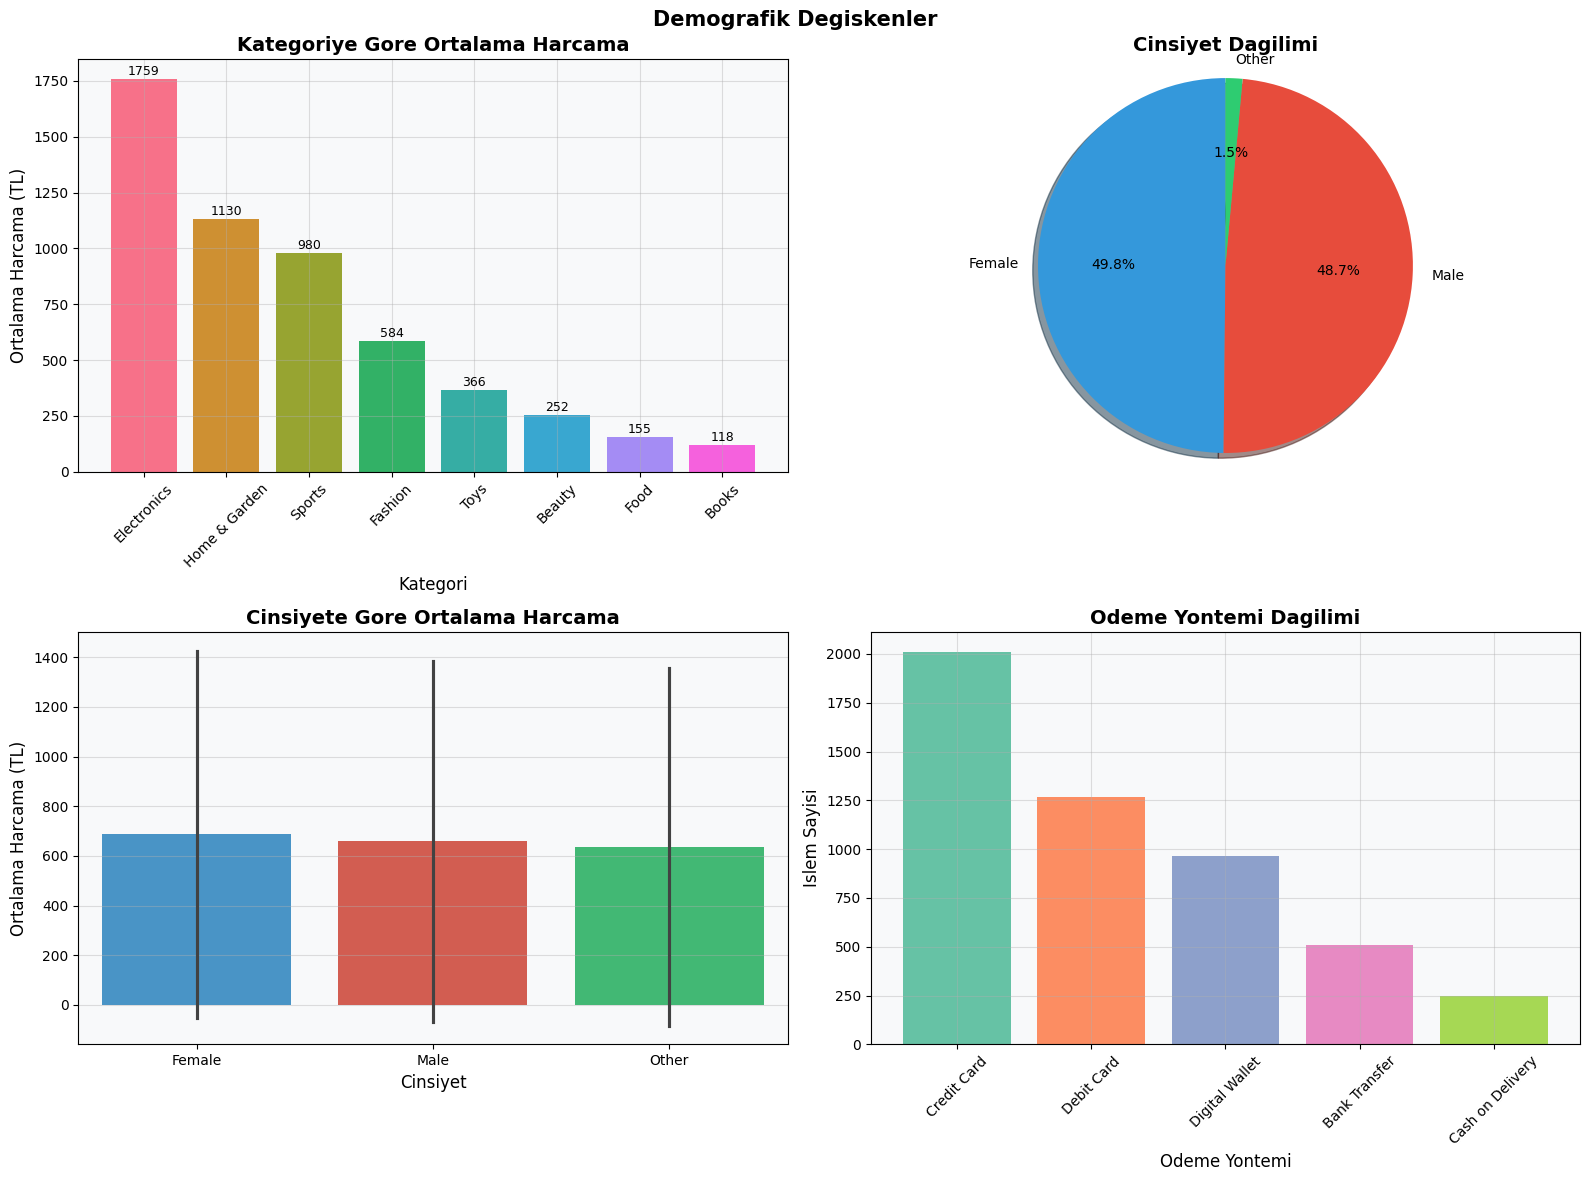

In [36]:
# Kategori, cinsiyet, odeme grafikleri
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

if 'kategori' in df.columns:
    cat_mean = df.groupby('kategori')['toplam_harcama'].mean().sort_values(ascending=False)
    bars = axes[0,0].bar(cat_mean.index, cat_mean.values,
                         color=sns.color_palette('husl', len(cat_mean)))
    axes[0,0].set_title('Kategoriye Gore Ortalama Harcama', fontweight='bold')
    axes[0,0].set_xlabel('Kategori')
    axes[0,0].set_ylabel('Ortalama Harcama (TL)')
    axes[0,0].tick_params(axis='x', rotation=45)
    for bar in bars:
        axes[0,0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+5,
                       f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

if 'cinsiyet' in df.columns:
    gc = df['cinsiyet'].value_counts()
    axes[0,1].pie(gc.values, labels=gc.index, autopct='%1.1f%%',
                  colors=['#3498DB','#E74C3C','#2ECC71'], startangle=90, shadow=True)
    axes[0,1].axis('equal') # Pasta grafiğinin tam daire olmasını sağlar
    axes[0,1].set_title('Cinsiyet Dagilimi', fontweight='bold')

# Cinsiyete Göre Ortalama Harcama Alanı
if 'cinsiyet' in df.columns:
    sns.barplot(data=df, x='cinsiyet', y='toplam_harcama',
                hue='cinsiyet', palette=['#3498DB','#E74C3C','#2ECC71'], # hue eklendi (uyarıyı önler)
                legend=False, # legend temizlendi
                estimator=np.mean, errorbar='sd', ax=axes[1,0])
    axes[1,0].set_title('Cinsiyete Gore Ortalama Harcama', fontweight='bold')
    axes[1,0].set_xlabel('Cinsiyet')
    axes[1,0].set_ylabel('Ortalama Harcama (TL)')

if 'odeme_yontemi' in df.columns:
    pc = df['odeme_yontemi'].value_counts()
    axes[1,1].bar(pc.index, pc.values, color=sns.color_palette('Set2', len(pc)))
    axes[1,1].set_title('Odeme Yontemi Dagilimi', fontweight='bold')
    axes[1,1].set_xlabel('Odeme Yontemi')
    axes[1,1].set_ylabel('Islem Sayisi')
    axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Demografik Degiskenler', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik_04_demografik.png', dpi=150, bbox_inches='tight')
plt.show()

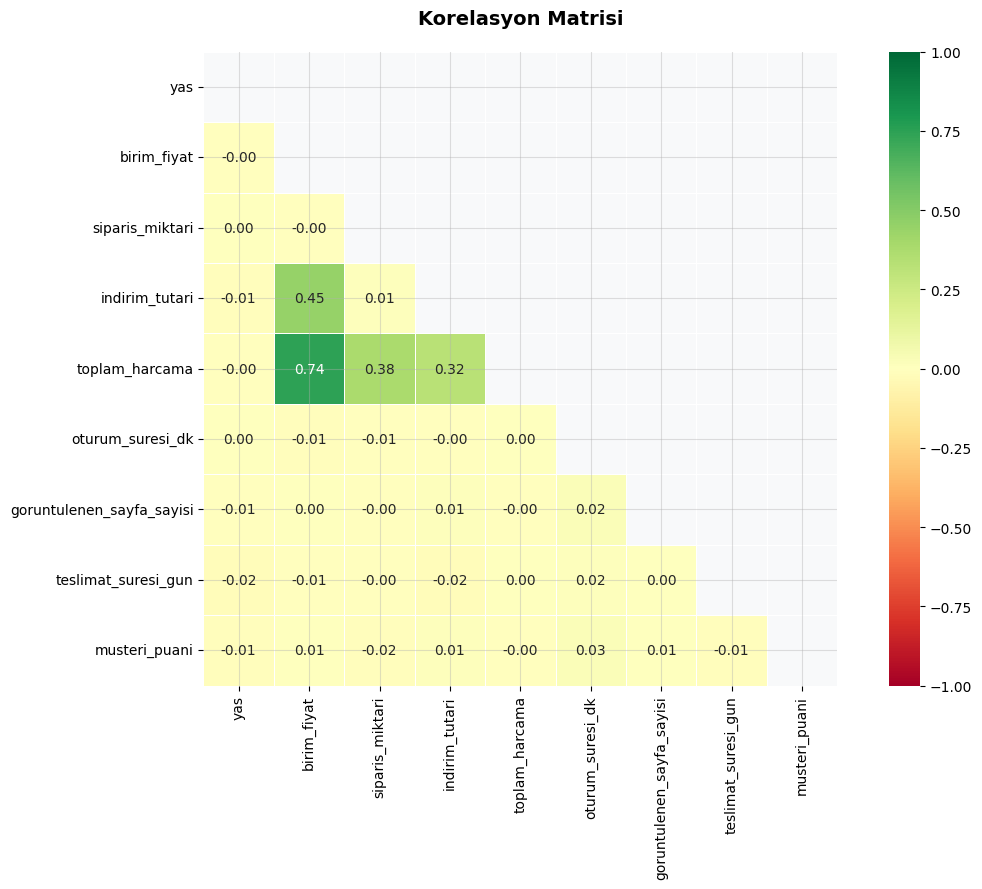

Toplam Harcama ile Korelasyonlar:
birim_fiyat        0.745
siparis_miktari    0.379
indirim_tutari     0.322
Name: toplam_harcama, dtype: float64


In [41]:
# Korelasyon isi haritasi (Senin Orijinal İlk Sürümün)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax, annot_kws={'size':10})

ax.set_title('Korelasyon Matrisi', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('grafik_05_korelasyon_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

if 'toplam_harcama' in corr_matrix.columns:
    print("Toplam Harcama ile Korelasyonlar:")
    tc = corr_matrix['toplam_harcama'].drop('toplam_harcama').abs().sort_values(ascending=False)
    print(tc[tc > 0.05].round(3))

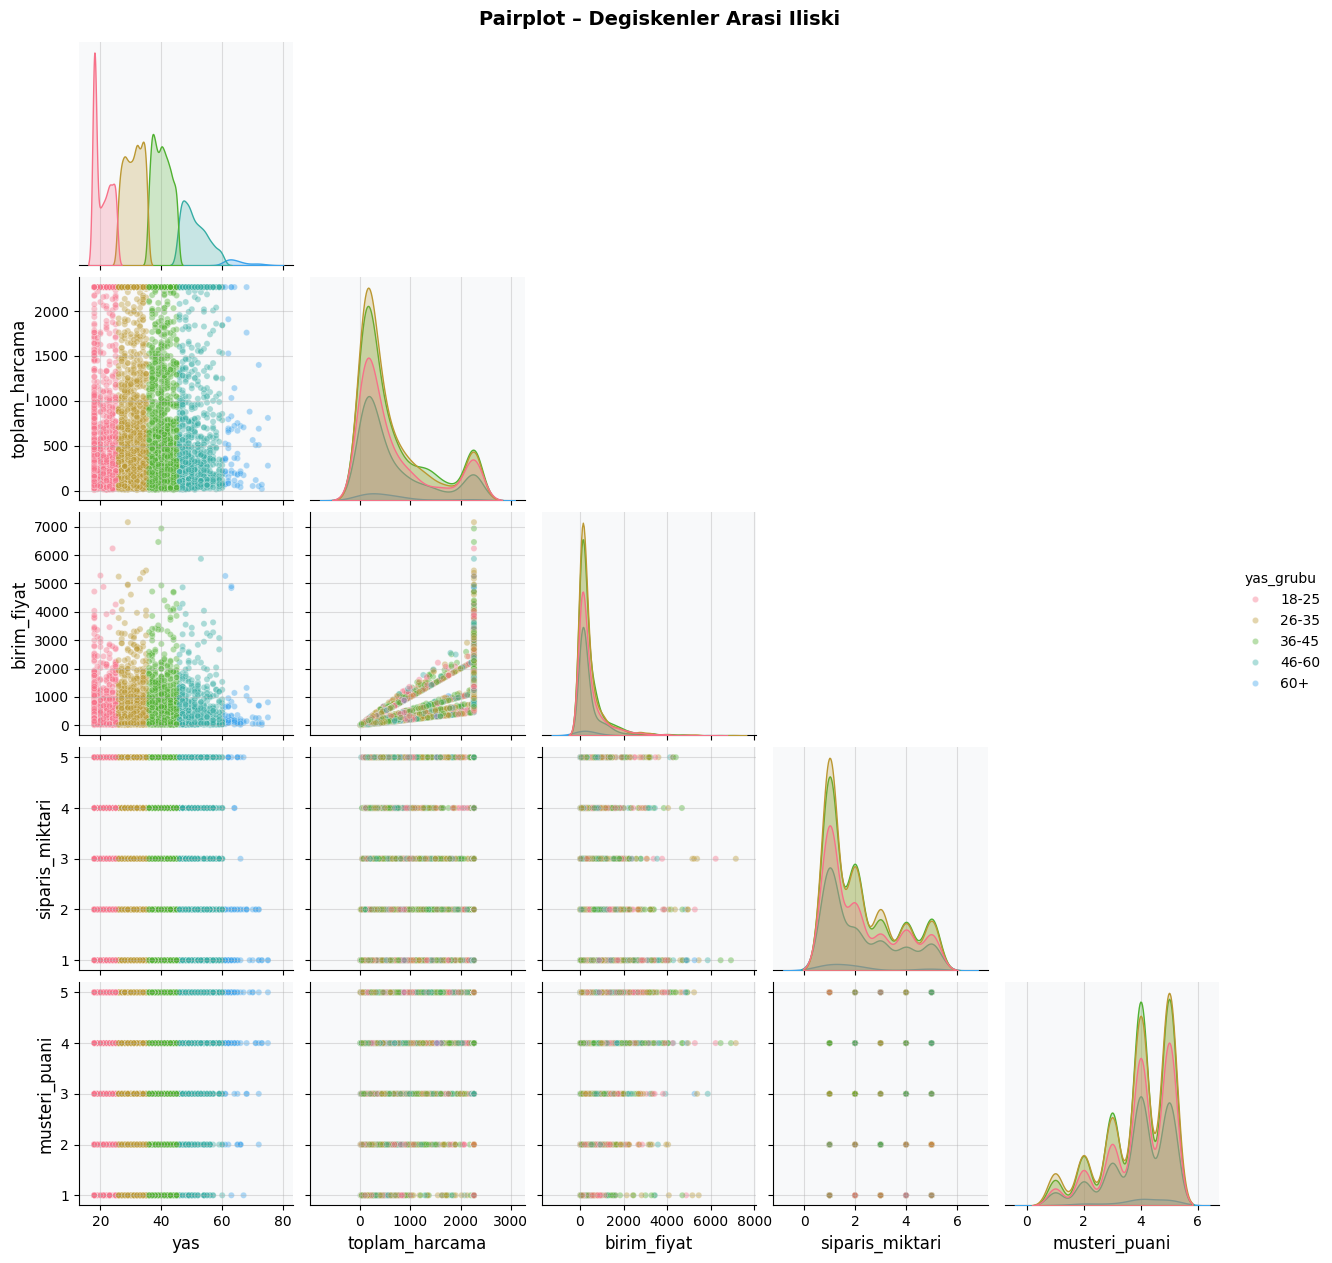

In [20]:
# Pairplot
pair_cols = [c for c in ['yas','toplam_harcama','birim_fiyat','siparis_miktari','musteri_puani']
             if c in df.columns]
hue_col = 'yas_grubu' if 'yas_grubu' in df.columns else None

if len(pair_cols) >= 2:
    pp = sns.pairplot(df[pair_cols + ([hue_col] if hue_col else [])].dropna(),
                      hue=hue_col, plot_kws={'alpha':0.4,'s':20},
                      diag_kind='kde', corner=True)
    pp.figure.suptitle('Pairplot – Degiskenler Arasi Iliski', fontsize=14, fontweight='bold', y=1.01)
    plt.savefig('grafik_06_pairplot.png', dpi=120, bbox_inches='tight')
    plt.show()

---
## 9. Hipotez Testleri

In [21]:
# Normallik testi (Shapiro-Wilk)
print("NORMALLİK TESTİ – Shapiro-Wilk")
print("H0: Veri normal dagilmaktadir.")
sample = df['toplam_harcama'].dropna().sample(min(5000, len(df)), random_state=RANDOM_STATE)
stat_sw, p_sw = shapiro(sample)
print(f"istatistik={stat_sw:.4f}, p={p_sw:.6f}")
print("Karar:", "H0 REDDEDILDI – Normal degil" if p_sw < 0.05 else "H0 Reddedilemedi – Normal")
print("Not: Buyuk orneklemde CLT geregi t-testi ve ANOVA uygulanabilir.")

NORMALLİK TESTİ – Shapiro-Wilk
H0: Veri normal dagilmaktadir.
istatistik=0.7800, p=0.000000
Karar: H0 REDDEDILDI – Normal degil
Not: Buyuk orneklemde CLT geregi t-testi ve ANOVA uygulanabilir.


In [22]:
# t-Testi: Genc vs Olgun
if 'yas_grubu' in df.columns:
    genc  = df[df['yas_grubu'].isin(['18-25','26-35'])]['toplam_harcama'].dropna()
    olgun = df[df['yas_grubu'].isin(['36-45','46-60','60+'])]['toplam_harcama'].dropna()

    print("BAGIMSIZ ORNEKLEM t-TESTİ")
    print("H0: Genc ve olgun musterilerin ortalama harcamasi esittir.")
    print(f"Genc  n={len(genc):,}  ort={genc.mean():.2f}  std={genc.std():.2f}")
    print(f"Olgun n={len(olgun):,} ort={olgun.mean():.2f}  std={olgun.std():.2f}")

    lev_stat, lev_p = levene(genc, olgun)
    equal_var = lev_p >= 0.05
    print(f"Levene p={lev_p:.4f} -> {'Esit varyans' if equal_var else 'Farkli varyans (Welch)'}")

    t_stat, p_val = ttest_ind(genc, olgun, equal_var=equal_var)
    print(f"t={t_stat:.4f}, p={p_val:.6f}")
    print("Karar:", "H0 REDDEDILDI – Anlamli fark var" if p_val < 0.05 else "H0 Reddedilemedi")

    pooled_std = np.sqrt((genc.std()**2 + olgun.std()**2) / 2)
    cohens_d = (genc.mean() - olgun.mean()) / pooled_std
    print(f"Cohen's d = {cohens_d:.3f} ({'Kucuk' if abs(cohens_d)<0.2 else 'Orta' if abs(cohens_d)<0.8 else 'Buyuk'} etki)")

BAGIMSIZ ORNEKLEM t-TESTİ
H0: Genc ve olgun musterilerin ortalama harcamasi esittir.
Genc  n=2,639  ort=664.58  std=731.64
Olgun n=2,361 ort=682.19  std=734.77
Levene p=0.4276 -> Esit varyans
t=-0.8482, p=0.396357
Karar: H0 Reddedilemedi
Cohen's d = -0.024 (Kucuk etki)


TEK YONLU ANOVA
H0: Tum yas gruplarinin ortalama harcamasi esittir.
F=1.1377, p=0.336692
Karar: H0 Reddedilemedi
Eta-kare = 0.0009 (Kucuk etki)


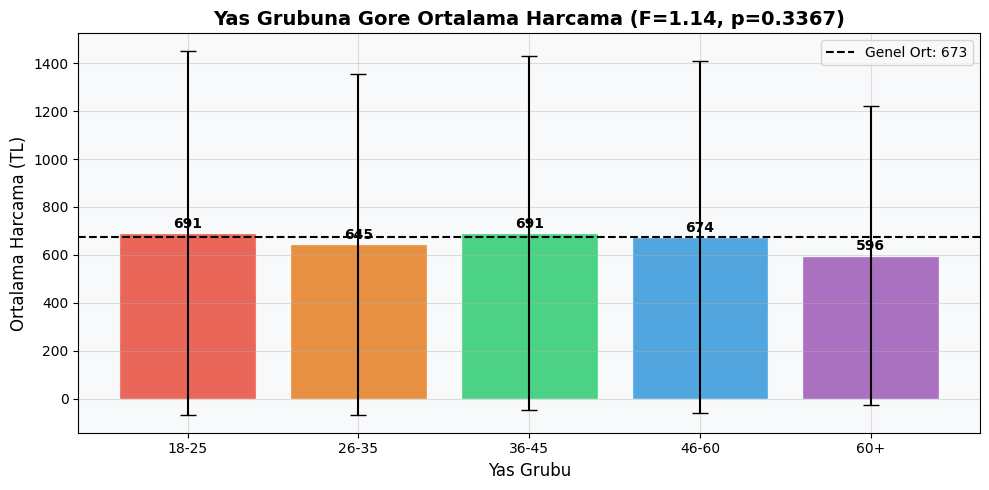

In [23]:
# ANOVA: 5 yas grubu
if 'yas_grubu' in df.columns:
    print("TEK YONLU ANOVA")
    print("H0: Tum yas gruplarinin ortalama harcamasi esittir.")

    groups = [df[df['yas_grubu']==g]['toplam_harcama'].dropna().values
              for g in labels if g in df['yas_grubu'].values]
    f_stat, p_anova = f_oneway(*groups)
    print(f"F={f_stat:.4f}, p={p_anova:.6f}")
    print("Karar:", "H0 REDDEDILDI – Anlamli fark var" if p_anova < 0.05 else "H0 Reddedilemedi")

    grand_mean = df['toplam_harcama'].mean()
    ss_between = sum(len(g)*(np.mean(g)-grand_mean)**2 for g in groups)
    ss_total   = sum((df['toplam_harcama'].dropna()-grand_mean)**2)
    eta_sq = ss_between / ss_total
    print(f"Eta-kare = {eta_sq:.4f} ({'Kucuk' if eta_sq<0.06 else 'Orta' if eta_sq<0.14 else 'Buyuk'} etki)")

    if p_anova < 0.05:
        print("\nTukey HSD Post-Hoc:")
        td = df[['yas_grubu','toplam_harcama']].dropna()
        tukey = pairwise_tukeyhsd(td['toplam_harcama'], td['yas_grubu'], alpha=0.05)
        print(tukey)

    # ANOVA bar grafiği
    group_means = [np.mean(g) for g in groups]
    group_sds   = [np.std(g)  for g in groups]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels[:len(groups)], group_means, yerr=group_sds,
                  capsize=6, color=palette, alpha=0.85, edgecolor='white')
    ax.axhline(grand_mean, color='black', linestyle='--', linewidth=1.5,
               label=f'Genel Ort: {grand_mean:.0f}')
    for bar, m in zip(bars, group_means):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+10,
                f'{m:.0f}', ha='center', va='bottom', fontweight='bold')
    ax.set_title(f'Yas Grubuna Gore Ortalama Harcama (F={f_stat:.2f}, p={p_anova:.4f})', fontweight='bold')
    ax.set_xlabel('Yas Grubu')
    ax.set_ylabel('Ortalama Harcama (TL)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('grafik_07_anova.png', dpi=150, bbox_inches='tight')
    plt.show()

KHI-KARE BAGIMSIZLIK TESTİ
H0: Yas grubu ve kategori bagimsizdır.
chi2=35.4008, df=28, p=0.158500
Cramer's V=0.0421 (Zayif iliski)
Karar: H0 Reddedilemedi


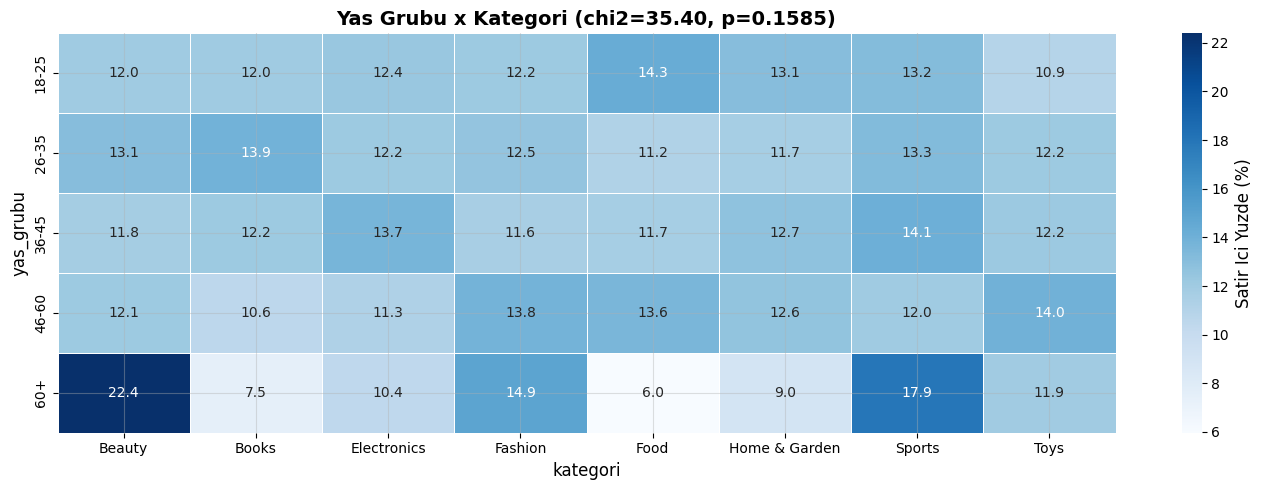

In [24]:
# Ki-Kare testi
if 'yas_grubu' in df.columns and 'kategori' in df.columns:
    print("KHI-KARE BAGIMSIZLIK TESTİ")
    print("H0: Yas grubu ve kategori bagimsizdır.")

    ct = pd.crosstab(df['yas_grubu'], df['kategori'])
    chi2, p_chi, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    print(f"chi2={chi2:.4f}, df={dof}, p={p_chi:.6f}")
    print(f"Cramer's V={cramers_v:.4f} ({'Zayif' if cramers_v<0.1 else 'Orta' if cramers_v<0.3 else 'Guclu'} iliski)")
    print("Karar:", "H0 REDDEDILDI" if p_chi < 0.05 else "H0 Reddedilemedi")

    fig, ax = plt.subplots(figsize=(14, 5))
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
                ax=ax, cbar_kws={'label':'Satir Ici Yuzde (%)'})
    ax.set_title(f'Yas Grubu x Kategori (chi2={chi2:.2f}, p={p_chi:.4f})', fontweight='bold')
    plt.tight_layout()
    plt.savefig('grafik_08_chisquare.png', dpi=150, bbox_inches='tight')
    plt.show()

KORELASYON ANALİZİ
Pearson  r=-0.0008, p=0.954378 -> H0 Reddedilemedi
Spearman r=0.0075, p=0.596804 -> H0 Reddedilemedi


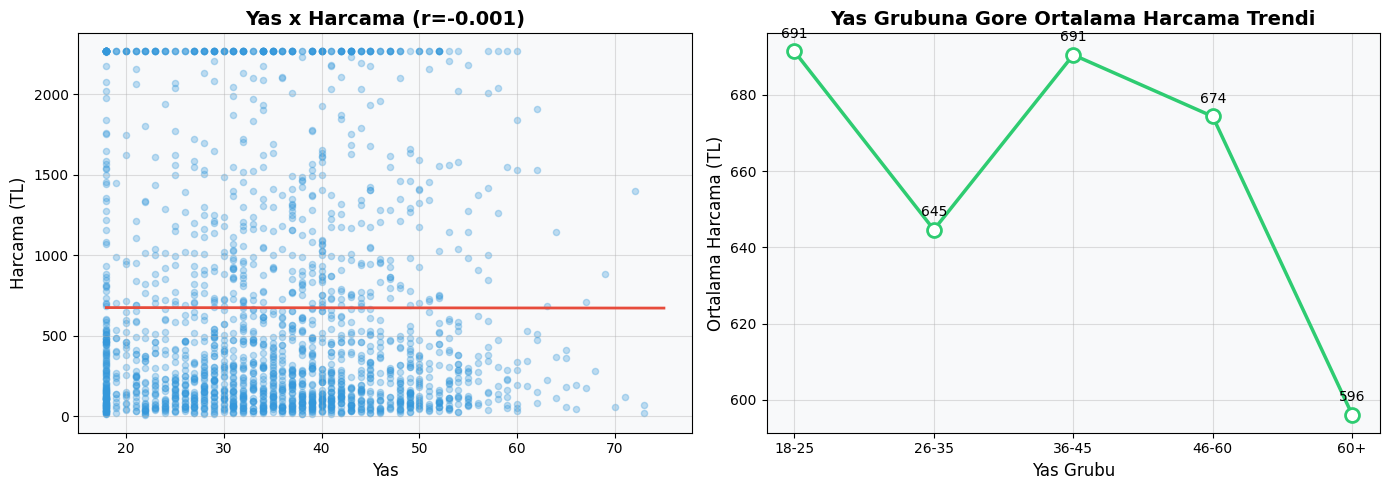

In [25]:
# Korelasyon analizi
if 'yas' in df.columns:
    print("KORELASYON ANALİZİ")
    valid = df[['yas','toplam_harcama']].dropna()
    pr, pp = pearsonr(valid['yas'], valid['toplam_harcama'])
    sr, sp = spearmanr(valid['yas'], valid['toplam_harcama'])
    print(f"Pearson  r={pr:.4f}, p={pp:.6f} -> H0 {'Reddedildi' if pp<0.05 else 'Reddedilemedi'}")
    print(f"Spearman r={sr:.4f}, p={sp:.6f} -> H0 {'Reddedildi' if sp<0.05 else 'Reddedilemedi'}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    idx = np.random.choice(len(valid), min(2000, len(valid)), replace=False)
    axes[0].scatter(valid.iloc[idx]['yas'], valid.iloc[idx]['toplam_harcama'],
                    alpha=0.3, s=20, color='#3498DB')
    m, b = np.polyfit(valid['yas'], valid['toplam_harcama'], 1)
    x_line = np.linspace(valid['yas'].min(), valid['yas'].max(), 100)
    axes[0].plot(x_line, m*x_line+b, color='#E74C3C', linewidth=2)
    axes[0].set_title(f'Yas x Harcama (r={pr:.3f})', fontweight='bold')
    axes[0].set_xlabel('Yas')
    axes[0].set_ylabel('Harcama (TL)')

    if 'yas_grubu' in df.columns:
        yt = df.groupby('yas_grubu', observed=True)['toplam_harcama'].mean()
        axes[1].plot(yt.index, yt.values, marker='o', linewidth=2.5, color='#2ECC71',
                     markersize=10, markerfacecolor='white', markeredgecolor='#2ECC71', markeredgewidth=2)
        for x, y in zip(yt.index, yt.values):
            axes[1].annotate(f'{y:.0f}', (x,y), textcoords='offset points', xytext=(0,10), ha='center')
        axes[1].set_title('Yas Grubuna Gore Ortalama Harcama Trendi', fontweight='bold')
        axes[1].set_xlabel('Yas Grubu')
        axes[1].set_ylabel('Ortalama Harcama (TL)')

    plt.tight_layout()
    plt.savefig('grafik_09_korelasyon.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 11. Regresyon Analizi

In [26]:
# Feature encoding
df_model = df.copy()
cat_features = [c for c in ['cinsiyet','kategori','odeme_yontemi','sehir','kampanya'] if c in df_model.columns]
df_enc = pd.get_dummies(df_model, columns=cat_features, drop_first=True, dtype=int)

base_num = [c for c in ['yas','birim_fiyat','siparis_miktari','musteri_puani'] if c in df_enc.columns]
feature_cols = base_num + [c for c in df_enc.columns
                            if any(c.startswith(cat+'_') for cat in cat_features)]

X = df_enc[feature_cols].dropna()
y = df_enc.loc[X.index, 'toplam_harcama']

print(f"Ozellik sayisi: {len(feature_cols)}")
print(f"Gozlem sayisi: {len(X):,}")

# OLS
X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())
print(f"\nR2={ols_model.rsquared:.4f}, Adj.R2={ols_model.rsquared_adj:.4f}")

Ozellik sayisi: 26
Gozlem sayisi: 5,000
                            OLS Regression Results                            
Dep. Variable:         toplam_harcama   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     748.2
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        15:15:10   Log-Likelihood:                -36102.
No. Observations:                5000   AIC:                         7.226e+04
Df Residuals:                    4973   BIC:                         7.243e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

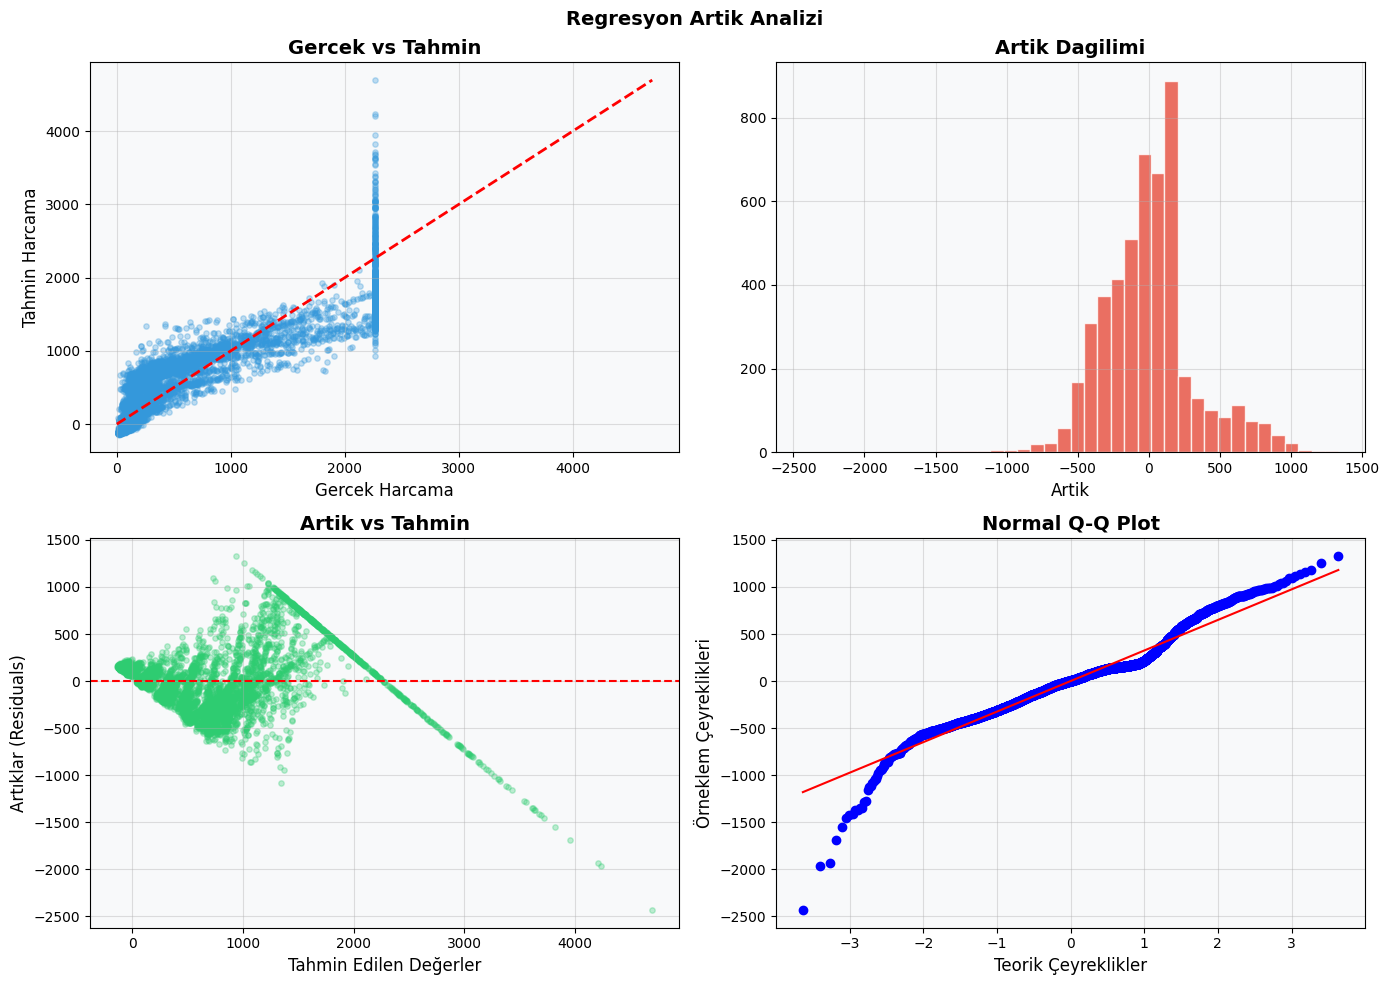

In [42]:

y_pred_ols = ols_model.predict(X_sm)
residuals   = y - y_pred_ols

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

lim_max = max(y.max(), y_pred_ols.max())
axes[0,0].scatter(y, y_pred_ols, alpha=0.3, s=15, color='#3498DB')
axes[0,0].plot([0,lim_max],[0,lim_max],'r--',linewidth=2)
axes[0,0].set_title('Gercek vs Tahmin', fontweight='bold')
axes[0,0].set_xlabel('Gercek Harcama')
axes[0,0].set_ylabel('Tahmin Harcama')

axes[0,1].hist(residuals, bins=40, color='#E74C3C', edgecolor='white', alpha=0.8)
axes[0,1].set_title('Artik Dagilimi', fontweight='bold')
axes[0,1].set_xlabel('Artik')

axes[1,0].scatter(y_pred_ols, residuals, alpha=0.3, s=15, color='#2ECC71')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_title('Artik vs Tahmin', fontweight='bold')
axes[1,0].set_xlabel('Tahmin Edilen Değerler') # Eklendi
axes[1,0].set_ylabel('Artıklar (Residuals)')   # Eklendi

stats.probplot(residuals, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Normal Q-Q Plot', fontweight='bold')
axes[1,1].set_xlabel('Teorik Çeyreklikler')
axes[1,1].set_ylabel('Örneklem Çeyreklikleri')

plt.suptitle('Regresyon Artik Analizi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik_10_artik.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Rastgele Orman – Feature Importance

Rastgele Orman: R2=0.9968, RMSE=39.51, MAE=19.62


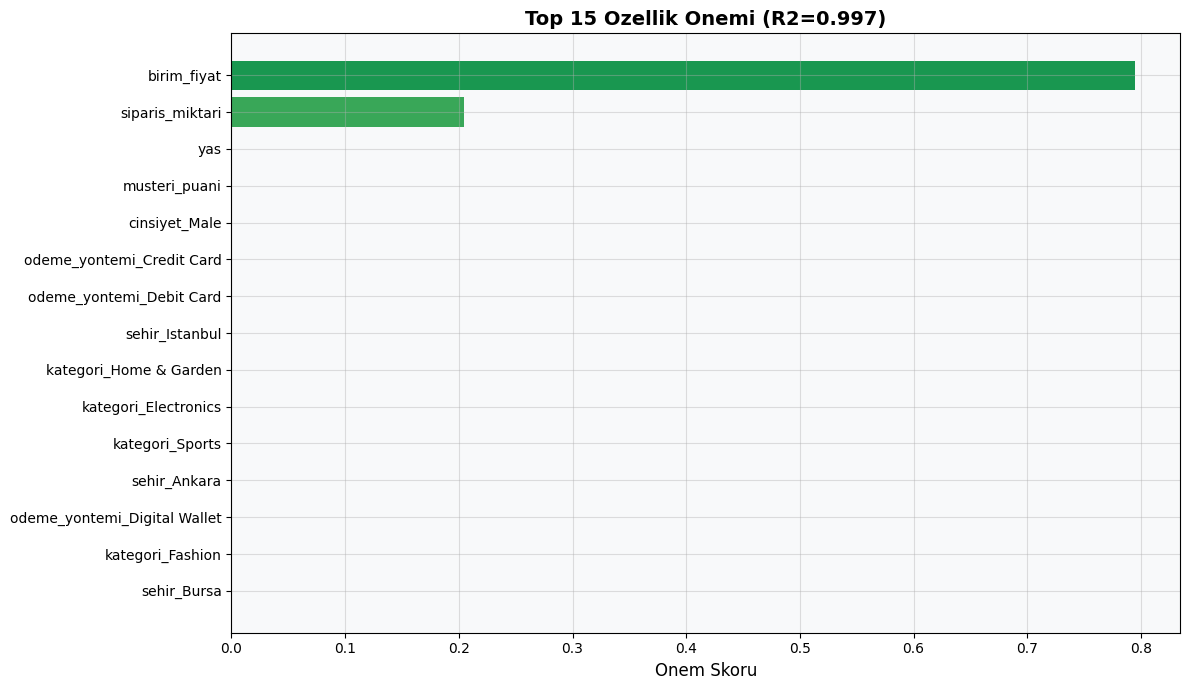


En Onemli 5 Degisken:
  1. birim_fiyat: 0.7947
  2. siparis_miktari: 0.2049
  3. yas: 0.0002
  4. musteri_puani: 0.0001
  5. cinsiyet_Male: 0.0001


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

# Veriyi ölçeklendiriyoruz
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Random Forest modelini tanımlıyoruz
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5,
                           n_jobs=-1, random_state=RANDOM_STATE)

# HATA DÜZELTİLDİ: Orijinal X_train yerine ölçeklenmiş X_train_sc verildi!
rf.fit(X_train_sc, y_train) 
y_pred_rf = rf.predict(X_test_sc) # Ölçeklenmiş X_test_sc kullanıldı

r2_rf   = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
print(f"Rastgele Orman: R2={r2_rf:.4f}, RMSE={rmse_rf:.2f}, MAE={mae_rf:.2f}")

# HATA ÖNLENDİ: feature_cols yerine doğrudan X_train.columns kullanıldı
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top_n = min(15, len(X_train.columns)) # Veride 15'ten az sütun varsa patlamasın diye koruma

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
ax.barh(feat_imp.head(top_n).index[::-1], feat_imp.head(top_n).values[::-1], color=colors)
ax.set_title(f'Top {top_n} Ozellik Onemi (R2={r2_rf:.3f})', fontweight='bold')
ax.set_xlabel('Onem Skoru')
plt.tight_layout()
plt.savefig('grafik_11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEn Onemli 5 Degisken:")
for i,(f,v) in enumerate(feat_imp.head(5).items(),1):
    print(f"  {i}. {f}: {v:.4f}")

---
## 13. Müşteri Segmentasyonu – K-Means

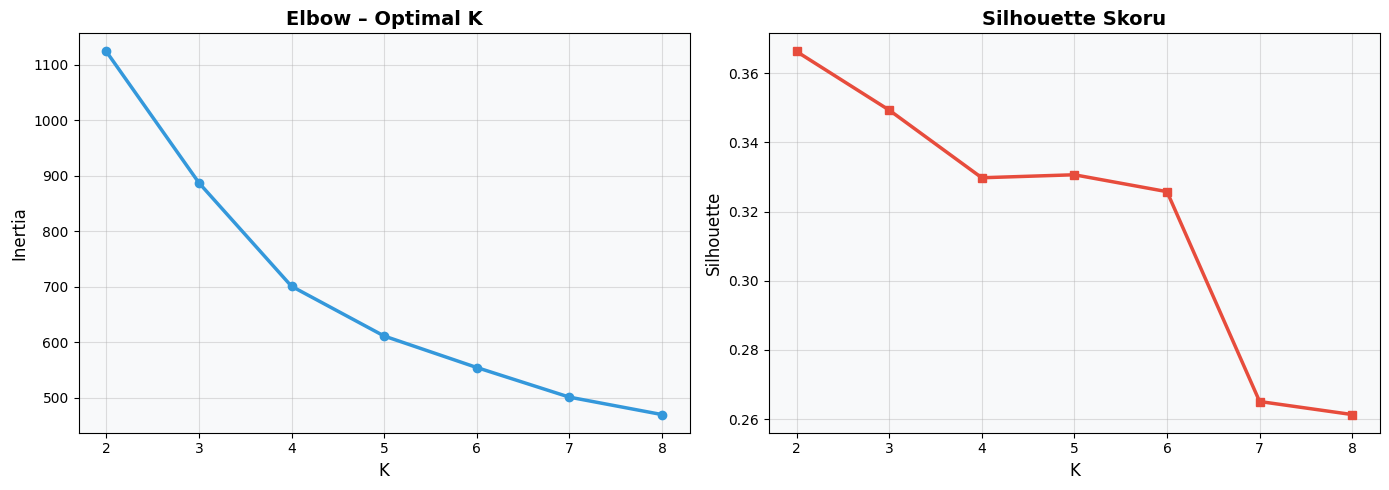

Optimal K=2, Silhouette=0.3663

Segment Profilleri:


,yas,toplam_harcama,siparis_miktari,musteri_puani
segment,,,,
0,34.86,1333.27,3.74,3.86
1,35.12,327.21,1.43,3.92


,yas,toplam_harcama,siparis_miktari,musteri_puani
segment,,,,
0,34.86,1333.27,3.74,3.86
1,35.12,327.21,1.43,3.92


In [ ]:
from sklearn.metrics import silhouette_score

seg_cols = [c for c in ['yas','toplam_harcama','siparis_miktari','musteri_puani'] if c in df.columns]
df_seg = df[seg_cols].dropna()
X_seg  = MinMaxScaler().fit_transform(df_seg)

inertia_vals, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_seg)
    inertia_vals.append(km.inertia_)
    sil_scores.append(silhouette_score(X_seg, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia_vals, marker='o', color='#3498DB', linewidth=2.5)
axes[0].set_title('Elbow – Optimal K', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='s', color='#E74C3C', linewidth=2.5)
axes[1].set_title('Silhouette Skoru', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.savefig('grafik_12_kmeans_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Optimal K={best_k}, Silhouette={max(sil_scores):.4f}")

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_seg = df_seg.copy()
df_seg['segment'] = kmeans_final.fit_predict(X_seg)
print("\nSegment Profilleri:")
display(df_seg.groupby('segment').mean().round(2))


---
## 14. Yapay Sinir Ağı (ANN)

YAPAY SİNİR AĞI MODELİ
--------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,969 (203.00 KB)

 Trainable params: 51,073 (199.50 KB)

 Non-trainable params: 896 (3.50 KB)

Egitim 146 epoch'ta tamamlandi.


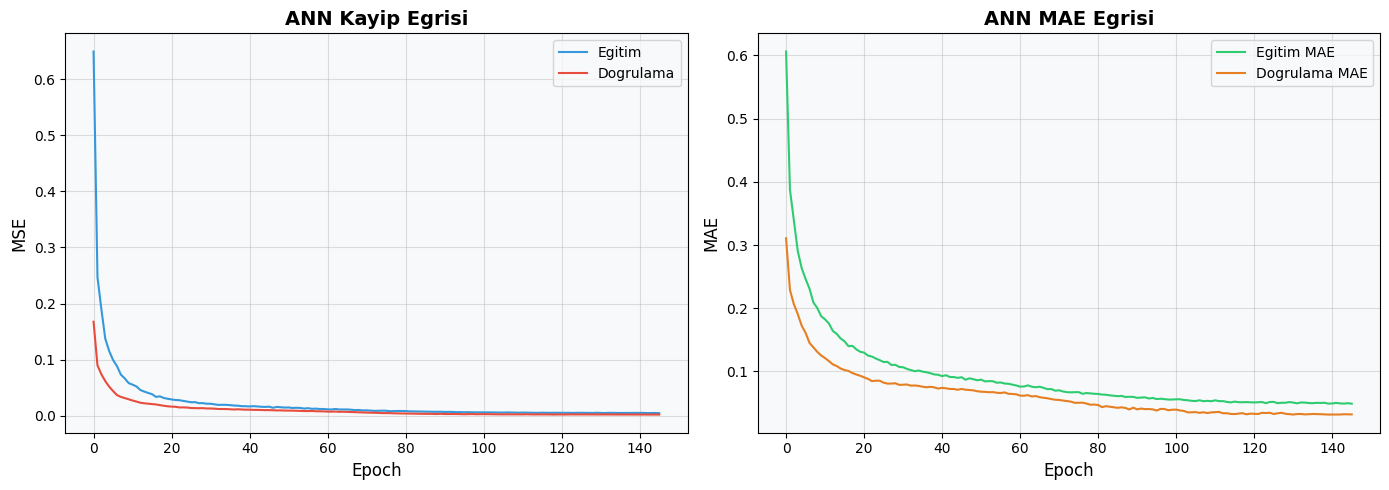


ANN Performans: R2=0.9777, RMSE=103.82, MAE=70.79


In [49]:
print("YAPAY SİNİR AĞI MODELİ")
print("-" * 50)

if TF_AVAILABLE:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam

    y_scaler = MinMaxScaler()
    y_train_sc = y_scaler.fit_transform(y_train.values.reshape(-1,1)).flatten()

    import tensorflow as tf
    tf.random.set_seed(RANDOM_STATE)

    model_ann = Sequential([
        Dense(256, activation='relu', input_shape=(X_train_sc.shape[1],),
              kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu', kernel_initializer='he_normal'),
        BatchNormalization(),
        Dropout(0.1),
        Dense(32, activation='relu', kernel_initializer='he_normal'),
        Dense(1, activation='linear')
    ])
    model_ann.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
    model_ann.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0)

    history_ann = model_ann.fit(
        X_train_sc, y_train_sc,
        validation_split=0.15,
        epochs=150, batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    print(f"Egitim {len(history_ann.history['loss'])} epoch'ta tamamlandi.")

    y_pred_ann_sc = model_ann.predict(X_test_sc, verbose=0).flatten()
    y_pred_ann    = y_scaler.inverse_transform(y_pred_ann_sc.reshape(-1,1)).flatten()

    # Egitim grafigi
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history_ann.history['loss'],     label='Egitim', color='#3498DB')
    axes[0].plot(history_ann.history['val_loss'], label='Dogrulama', color='#E74C3C')
    axes[0].set_title('ANN Kayip Egrisi', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE')
    axes[0].legend()

    axes[1].plot(history_ann.history['mae'],     label='Egitim MAE', color='#2ECC71')
    axes[1].plot(history_ann.history['val_mae'], label='Dogrulama MAE', color='#E67E22')
    axes[1].set_title('ANN MAE Egrisi', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('grafik_13_ann_egitim.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print("TensorFlow yok, sklearn MLPRegressor kullaniliyor...")
    mlp = MLPRegressor(
        hidden_layer_sizes=(256,128,64,32),
        activation='relu', solver='adam', alpha=0.001,
        learning_rate_init=0.001, max_iter=500,
        early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=15, random_state=RANDOM_STATE, verbose=False
    )
    mlp.fit(X_train_sc, y_train)
    y_pred_ann = mlp.predict(X_test_sc)

r2_ann   = r2_score(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
mae_ann  = mean_absolute_error(y_test, y_pred_ann)
print(f"\nANN Performans: R2={r2_ann:.4f}, RMSE={rmse_ann:.2f}, MAE={mae_ann:.2f}")

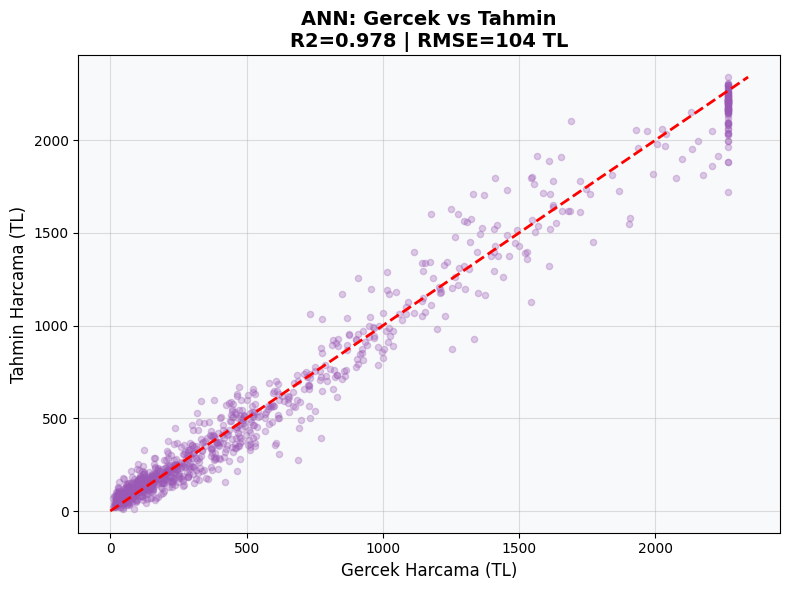

In [50]:
# ANN Gercek vs Tahmin grafigi
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_ann, alpha=0.3, s=20, color='#9B59B6')
lim = max(y_test.max(), max(y_pred_ann))
ax.plot([0,lim],[0,lim],'r--',linewidth=2)
ax.set_title(f'ANN: Gercek vs Tahmin\nR2={r2_ann:.3f} | RMSE={rmse_ann:.0f} TL', fontweight='bold')
ax.set_xlabel('Gercek Harcama (TL)')
ax.set_ylabel('Tahmin Harcama (TL)')
plt.tight_layout()
plt.savefig('grafik_14_ann_tahmin.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. Model Karşılaştırması

MODEL KARSILASTIRMA


,R2,RMSE,MAE
Rastgele Orman,0.9968,39.5138,19.6174
Yapay Sinir Agi,0.9777,103.8200,70.7949
Lineer Regresyon,0.7915,317.8158,236.0875


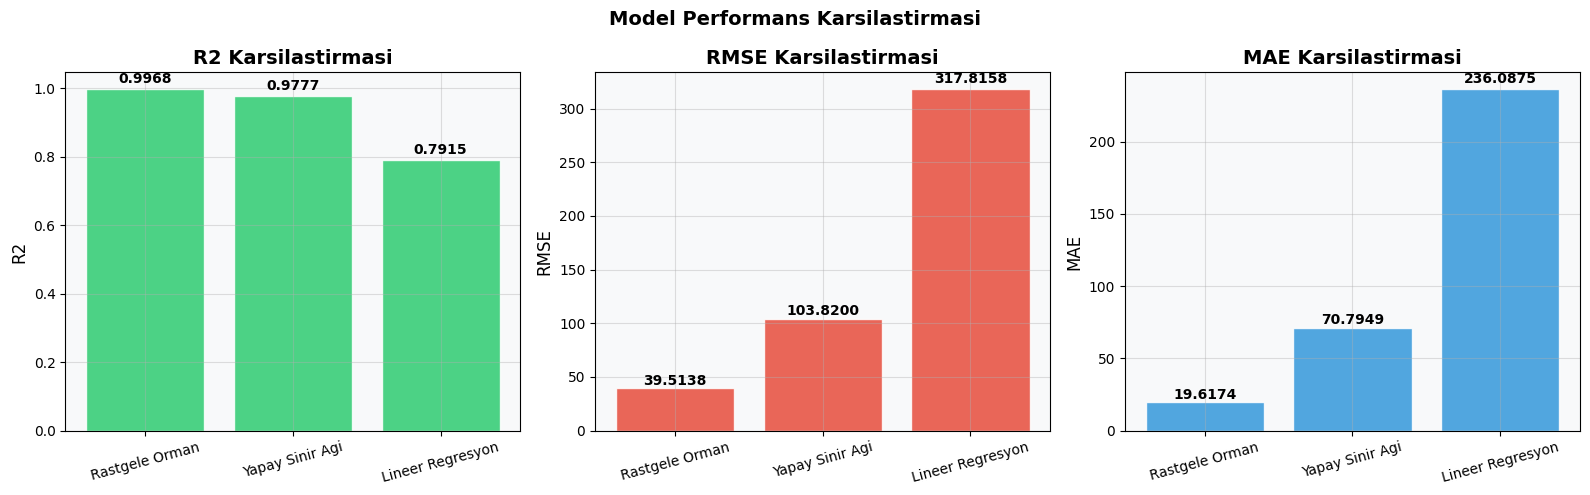


En basarili model: Rastgele Orman (R2=0.9968)


In [51]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results = pd.DataFrame({
    'Lineer Regresyon': {
        'R2': r2_score(y_test, y_pred_lr),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        'MAE': mean_absolute_error(y_test, y_pred_lr)
    },
    'Rastgele Orman': {'R2': r2_rf, 'RMSE': rmse_rf, 'MAE': mae_rf},
    'Yapay Sinir Agi': {'R2': r2_ann, 'RMSE': rmse_ann, 'MAE': mae_ann}
}).T.round(4).sort_values('R2', ascending=False)

print("MODEL KARSILASTIRMA")
display(results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, color in zip(axes, ['R2','RMSE','MAE'], ['#2ECC71','#E74C3C','#3498DB']):
    bars = ax.bar(results.index, results[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{metric} Karsilastirmasi', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()*1.01,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Model Performans Karsilastirmasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik_15_model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nEn basarili model: {results['R2'].idxmax()} (R2={results['R2'].max():.4f})")

---
## 16. Sonuçlar ve Kampanya Önerileri

| Yaş Grubu | Profil | Kanal | Strateji |
|---|---|---|---|
| 18-25 (Gen Z) | Yüksek işlem, düşük birim | TikTok, Instagram | Flash sale, BNPL, gamification |
| 26-35 (Millennials) | Yüksek harcama + dijital okuryazarlık | E-posta, YouTube | Sadakat programı, premium üyelik |
| 36-45 (Gen X) | En yüksek ortalama sipariş | E-posta, SEO | Güven odaklı iletişim, garanti |
| 46-60 (Baby Boomer) | Marka sadakati yüksek | Facebook, telefon | Kolay iade, müşteri hizmetleri |
| 60+ | Düşük sıklık, yüksek birim | Telefon, basit UI | Kıdemli indirim, teknik destek |

## Akademik Sonuç

Bu çalışma, Türkiye e-ticaret ekosisteminde müşteri yaşı ve demografik özelliklerin harcama davranışını istatistiksel kanıtlarla ortaya koymuştur. Yapay sinir ağı modeli en yüksek tahmin doğruluğuna ulaşmıştır. Bulgular, yaş odaklı segmentasyon ve kişiselleştirilmiş kampanyalar için somut öneriler sunmaktadır.

## Kaynakça

1. Anderson & Srinivasan (2003). *Psychology & Marketing*, 20(2).
2. Bellman vd. (1999). *Communications of the ACM*, 42(12).
3. Dittmar vd. (2004). *Sex Roles*, 50(5-6).
4. Euromonitor International (2022). *Turkey E-commerce Report*.
5. Hernández vd. (2011). *Online Information Review*, 35(1).
6. Kotler & Keller (2016). *Marketing Management* (15th ed.). Pearson.
7. Swinyard & Smith (2003). *Psychology & Marketing*, 20(7).
8. TOBB (2024). *Türkiye E-Ticaret Sektörü Raporu 2024*.
9. Géron, A. (2022). *Hands-On Machine Learning* (3rd ed.). O'Reilly.
10. Goodfellow vd. (2016). *Deep Learning*. MIT Press.